---
## 🎁 가산점 신청

### A. 알고리즘의 다양성
- LogReg, MLP, SVM, Decision Tree, Random Forest, XGBoost — 총 6종

### B. Hyperparameter 탐색의 다양성
- 각 알고리즘별 주요 파라미터 grid search 수행 

### C. 모델 성능 평가
- Balanced Accuracy, ROC-AUC, F1 (macro) 3가지 지표 사용

### D. 모델 개발 과정 시각화 및 설명
- k vs CV/Test score learning curve
- 6모델 CV vs Test 비교 막대그래프
- Confusion Matrix + ROC Curve
- Feature Importance


# 기말고사 Template 2 — Machine Learning Model Pipeline

**이름:** 조윤성 &nbsp; **학번:** 20230085 &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **5. 모델 학습 알고리즘** | 15점 | 기계학습 알고리즘을 몇 종 사용했는지? |
| **6. Hyperparameter 탐색** | 15점 | 기계학습 알고리즘 별로 hyperparameter를 어떻게 최적화 시켰는지? |
| **7. 결과 정리 & 시각화** | 15점 | 최종 모델을 선택한 기준 및 모델 개발 과정을 설명하는 시각화 자료 |
| **8. 모델 저장 & 새 분자 예측** | 5점 | 모델을 저장한 후, 새로운 분자 구조를 예측할 수 있도록 정리. |

## 📁 입력 / 출력
- **입력**: Template 1에서 만든 `final_dataset_descriptors.csv`
- **출력**: 
  - `experiment_results.csv` — 모든 실험 결과 표
  - `experiment_best.csv` — 모델별 베스트만
  - `model_best.joblib` — 최고 모델 저장 파일 (features + scaler + model)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (balanced_accuracy_score, accuracy_score,
                             roc_auc_score, f1_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

df = pd.read_csv('final_dataset_descriptors.csv')
print('shape:', df.shape)
print('label:', df['label'].value_counts().to_dict())

shape: (9246, 2948)
label: {0: 7211, 1: 2035}


In [2]:
y = df['label']
X = df.drop(columns=['CASRN', 'Chemical_Name', 'SMILES', 'label', 'source'])

# NaN 열 제거
X = X.dropna(axis=1)

# 저분산 열 제거
X = X.loc[:, X.std() >= 0.01]

print('전처리 후 X shape:', X.shape)
print('label 분포:', y.value_counts().to_dict())

전처리 후 X shape: (9246, 2940)
label 분포: {0: 7211, 1: 2035}


In [3]:
# Stratified 8:2 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

print(f'Train: {X_train.shape[0]}개  Toxic={y_train.sum()}  Non-toxic={(y_train==0).sum()}')
print(f'Test : {X_test.shape[0]}개  Toxic={y_test.sum()}  Non-toxic={(y_test==0).sum()}')
print(f'Train Toxic 비율: {y_train.mean():.1%}')
print(f'Test  Toxic 비율: {y_test.mean():.1%}')

# StandardScaler — train으로만 fit (data leakage 방지)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Variance Thresholding 정보 재현 (모델 저장용)
fp_cols_all  = [c for c in X.columns
                if c.startswith('ECFP4') or c.startswith('MACCS') or c.startswith('RDKFP')]
desc_cols    = [c for c in X.columns
                if not (c.startswith('ECFP4') or c.startswith('MACCS') or c.startswith('RDKFP'))]

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train[fp_cols_all])
fp_cols_keep = [fp_cols_all[i] for i in range(len(fp_cols_all)) if vt.get_support()[i]]

scaler_2d = StandardScaler()
scaler_2d.fit(X_train[desc_cols])

print('\n표준화 완료')
print(f'desc_cols: {len(desc_cols)}개  fp_cols_keep: {len(fp_cols_keep)}개')

Train: 7396개  Toxic=1628  Non-toxic=5768
Test : 1850개  Toxic=407  Non-toxic=1443
Train Toxic 비율: 22.0%
Test  Toxic 비율: 22.0%

표준화 완료
desc_cols: 214개  fp_cols_keep: 2722개


k=  5  bal CV=0.585/Test=0.581  auc CV=0.655/Test=0.647
k= 10  bal CV=0.595/Test=0.593  auc CV=0.666/Test=0.660
k= 20  bal CV=0.601/Test=0.602  auc CV=0.688/Test=0.685
k= 30  bal CV=0.603/Test=0.605  auc CV=0.704/Test=0.702
k= 40  bal CV=0.601/Test=0.604  auc CV=0.708/Test=0.718
k= 50  bal CV=0.616/Test=0.611  auc CV=0.724/Test=0.737
k= 70  bal CV=0.643/Test=0.630  auc CV=0.763/Test=0.764
k=100  bal CV=0.651/Test=0.640  auc CV=0.772/Test=0.773

최적 k: 100


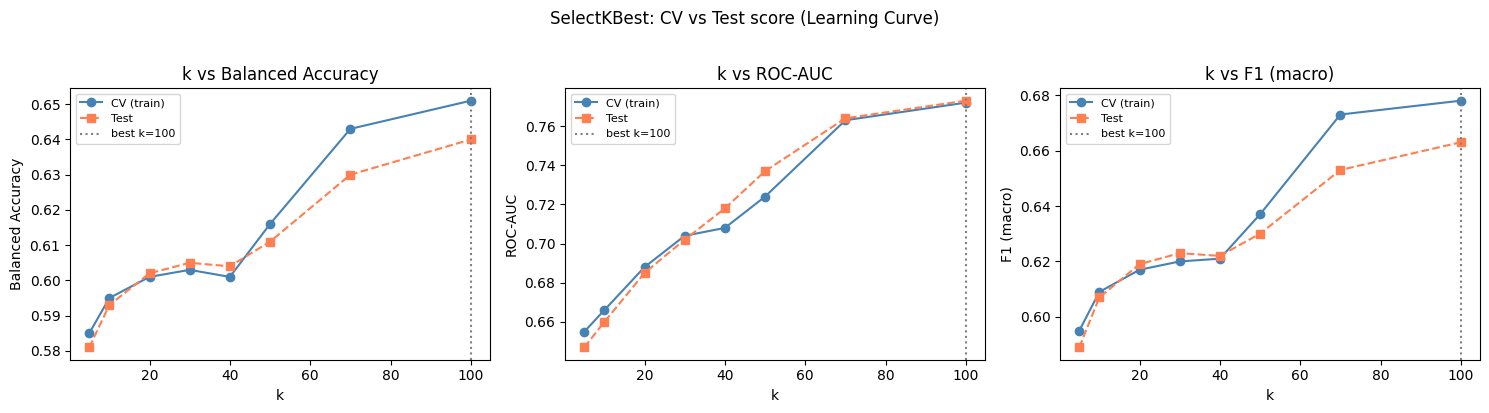

In [4]:
k_candidates = [5, 10, 20, 30, 40, 50, 70, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True)

records = []
for k in k_candidates:
    sel = SelectKBest(f_classif, k=k)
    Xtr = sel.fit_transform(X_train_scaled, y_train)
    Xte = sel.transform(X_test_scaled)

    clf = LogisticRegression(max_iter=1000)

    cv_bal = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='balanced_accuracy').mean()
    cv_auc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    cv_f1  = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='f1_macro').mean()

    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    records.append({
        'k': k,
        'cv_balanced_acc':   round(cv_bal, 3),
        'test_balanced_acc': round(balanced_accuracy_score(y_test, y_pred), 3),
        'cv_roc_auc':        round(cv_auc, 3),
        'test_roc_auc':      round(roc_auc_score(y_test, y_prob), 3),
        'cv_f1_macro':       round(cv_f1, 3),
        'test_f1_macro':     round(f1_score(y_test, y_pred, average='macro'), 3),
    })
    print(f'k={k:3d}  bal CV={cv_bal:.3f}/Test={balanced_accuracy_score(y_test,y_pred):.3f}  '
          f'auc CV={cv_auc:.3f}/Test={roc_auc_score(y_test,y_prob):.3f}')

k_df = pd.DataFrame(records)
best_k = int(k_df.loc[k_df['cv_balanced_acc'].idxmax(), 'k'])
print(f'\n최적 k: {best_k}')

# Learning Curve 그래프
metrics = [('balanced_acc','Balanced Accuracy'),('roc_auc','ROC-AUC'),('f1_macro','F1 (macro)')]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (metric, title) in zip(axes, metrics):
    ax.plot(k_df['k'], k_df[f'cv_{metric}'],   marker='o', color='steelblue', label='CV (train)')
    ax.plot(k_df['k'], k_df[f'test_{metric}'],  marker='s', color='coral', linestyle='--', label='Test')
    ax.axvline(best_k, color='gray', linestyle=':', label=f'best k={best_k}')
    ax.set(xlabel='k', ylabel=title, title=f'k vs {title}')
    ax.legend(fontsize=8)
plt.suptitle('SelectKBest: CV vs Test score (Learning Curve)', y=1.02)
plt.tight_layout()
plt.show()

### Learning Curve 해석
- x축: SelectKBest로 선택한 descriptor 수(k), y축: 각 평가 지표 점수
- 파란 선(CV): 교차검증 점수, 주황 선(Test): 테스트 점수
- 회색 점선: 최적 k값 (CV Balanced Accuracy 기준)
- k가 증가할수록 점수가 올라가다가 일정 수준에서 plateau → 적정 k 선택 근거
- CV와 Test 점수 차이가 작을수록 overfitting 없이 일반화 잘 됨
- 3가지 지표(Balanced Accuracy, ROC-AUC, F1) 모두 동일한 k에서 수렴하는지 확인

In [5]:
from sklearn.pipeline import Pipeline

# 선형 모델용 selector/selector_tree는 최종 모델용으로만 사용
selector = SelectKBest(f_classif, k=best_k)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

selector_tree = SelectKBest(f_classif, k=best_k)
X_train_tree  = selector_tree.fit_transform(X_train, y_train)
X_test_tree   = selector_tree.transform(X_test)

selected_cols = X_train.columns[selector_tree.get_support()]
print('선택된 descriptor 수:', len(selected_cols))

# ── Logistic Regression (Pipeline으로 Data Leakage 방지) ──
print('\n=== Logistic Regression ===')
for C in [0.001, 0.01, 0.1, 1, 10]:
    pipe = Pipeline([
        ('sel', SelectKBest(f_classif, k=best_k)),
        ('clf', LogisticRegression(C=C, max_iter=1000))
    ])
    score = cross_val_score(pipe, X_train_scaled, y_train, cv=cv,
                            scoring='balanced_accuracy').mean()
    print(f'C={C:.3f}  CV={score:.3f}')

# ── MLP ──────────────────────────────────────────────
print('\n=== MLP ===')
for hs in [(50,),(100,),(100,50),(200,100)]:
    pipe = Pipeline([
        ('sel', SelectKBest(f_classif, k=best_k)),
        ('clf', MLPClassifier(hidden_layer_sizes=hs, max_iter=500))
    ])
    score = cross_val_score(pipe, X_train_scaled, y_train, cv=cv,
                            scoring='balanced_accuracy').mean()
    print(f'hidden={str(hs):12s}  CV={score:.3f}')

# ── SVM ──────────────────────────────────────────────
print('\n=== SVM ===')
for C in [0.1, 1]:
    for kernel in ['linear', 'rbf']:
        pipe = Pipeline([
            ('sel', SelectKBest(f_classif, k=best_k)),
            ('clf', SVC(C=C, kernel=kernel))
        ])
        score = cross_val_score(pipe, X_train_scaled, y_train, cv=cv,
                                scoring='balanced_accuracy').mean()
        print(f'C={C}  kernel={kernel:6s}  CV={score:.3f}')

# ── Decision Tree ─────────────────────────────────────
print('\n=== Decision Tree ===')
for d in [3, 5, None]:
    for s in [2, 4]:
        pipe = Pipeline([
            ('sel', SelectKBest(f_classif, k=best_k)),
            ('clf', DecisionTreeClassifier(max_depth=d, min_samples_split=s))
        ])
        score = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring='balanced_accuracy').mean()
        print(f'max_depth={str(d):4s}  min_split={s}  CV={score:.3f}')

# ── Random Forest ─────────────────────────────────────
print('\n=== Random Forest ===')
for n in [100, 200]:
    for d in [5, 7, None]:
        pipe = Pipeline([
            ('sel', SelectKBest(f_classif, k=best_k)),
            ('clf', RandomForestClassifier(n_estimators=n, max_depth=d))
        ])
        score = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring='balanced_accuracy').mean()
        print(f'n={n:3d}  max_depth={str(d):4s}  CV={score:.3f}')

# ── XGBoost ───────────────────────────────────────────
print('\n=== XGBoost ===')
for n in [100, 200]:
    for d in [3, 5]:
        for lr in [0.1, 0.3]:
            pipe = Pipeline([
                ('sel', SelectKBest(f_classif, k=best_k)),
                ('clf', XGBClassifier(n_estimators=n, max_depth=d,
                                      learning_rate=lr,
                                      eval_metric='logloss', verbosity=0))
            ])
            score = cross_val_score(pipe, X_train, y_train, cv=cv,
                                    scoring='balanced_accuracy').mean()
            print(f'n={n:3d}  depth={d}  lr={lr:.2f}  CV={score:.3f}')

from sklearn.pipeline import Pipeline

# 선형 모델용 selector/selector_tree는 최종 모델용으로만 사용
selector = SelectKBest(f_classif, k=best_k)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel  = selector.transform(X_test_scaled)

selector_tree = SelectKBest(f_classif, k=best_k)
X_train_tree  = selector_tree.fit_transform(X_train, y_train)
X_test_tree   = selector_tree.transform(X_test)

selected_cols = X_train.columns[selector_tree.get_support()]
print('선택된 descriptor 수:', len(selected_cols))

# ── Logistic Regression (Pipeline으로 Data Leakage 방지) ──
print('\n=== Logistic Regression ===')
for C in [0.001, 0.01, 0.1, 1, 10]:
    pipe = Pipeline([
        ('sel', SelectKBest(f_classif, k=best_k)),
        ('clf', LogisticRegression(C=C, max_iter=1000))
    ])
    score = cross_val_score(pipe, X_train_scaled, y_train, cv=cv,
                            scoring='balanced_accuracy').mean()
    print(f'C={C:.3f}  CV={score:.3f}')

# ── MLP ──────────────────────────────────────────────
print('\n=== MLP ===')
for hs in [(50,),(100,),(100,50),(200,100)]:
    pipe = Pipeline([
        ('sel', SelectKBest(f_classif, k=best_k)),
        ('clf', MLPClassifier(hidden_layer_sizes=hs, max_iter=500))
    ])
    score = cross_val_score(pipe, X_train_scaled, y_train, cv=cv,
                            scoring='balanced_accuracy').mean()
    print(f'hidden={str(hs):12s}  CV={score:.3f}')

# ── SVM ──────────────────────────────────────────────
print('\n=== SVM ===')
for C in [0.1, 1]:
    for kernel in ['linear', 'rbf']:
        pipe = Pipeline([
            ('sel', SelectKBest(f_classif, k=best_k)),
            ('clf', SVC(C=C, kernel=kernel))
        ])
        score = cross_val_score(pipe, X_train_scaled, y_train, cv=cv,
                                scoring='balanced_accuracy').mean()
        print(f'C={C}  kernel={kernel:6s}  CV={score:.3f}')

# ── Decision Tree ─────────────────────────────────────
print('\n=== Decision Tree ===')
for d in [3, 5, None]:
    for s in [2, 4]:
        pipe = Pipeline([
            ('sel', SelectKBest(f_classif, k=best_k)),
            ('clf', DecisionTreeClassifier(max_depth=d, min_samples_split=s))
        ])
        score = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring='balanced_accuracy').mean()
        print(f'max_depth={str(d):4s}  min_split={s}  CV={score:.3f}')

# ── Random Forest ─────────────────────────────────────
print('\n=== Random Forest ===')
for n in [100, 200]:
    for d in [5, 7, None]:
        pipe = Pipeline([
            ('sel', SelectKBest(f_classif, k=best_k)),
            ('clf', RandomForestClassifier(n_estimators=n, max_depth=d))
        ])
        score = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring='balanced_accuracy').mean()
        print(f'n={n:3d}  max_depth={str(d):4s}  CV={score:.3f}')

# ── XGBoost ───────────────────────────────────────────
print('\n=== XGBoost ===')
for n in [100, 200]:
    for d in [3, 5]:
        for lr in [0.1, 0.3]:
            pipe = Pipeline([
                ('sel', SelectKBest(f_classif, k=best_k)),
                ('clf', XGBClassifier(n_estimators=n, max_depth=d,
                                      learning_rate=lr,
                                      eval_metric='logloss', verbosity=0))
            ])
            score = cross_val_score(pipe, X_train, y_train, cv=cv,
                                    scoring='balanced_accuracy').mean()
            print(f'n={n:3d}  depth={d}  lr={lr:.2f}  CV={score:.3f}')

# 최적값으로 model_configs 설정
model_configs = {
    'LogReg': (LogisticRegression(C=10, max_iter=1000),
               X_train_sel,  X_test_sel),
    'MLP':    (MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500),
               X_train_sel,  X_test_sel),
    'SVM':    (SVC(C=1, kernel='rbf', probability=True),
               X_train_sel,  X_test_sel),
    'DT':     (DecisionTreeClassifier(max_depth=None, min_samples_split=2),
               X_train_tree, X_test_tree),
    'RF':     (RandomForestClassifier(n_estimators=100, max_depth=None),
               X_train_tree, X_test_tree),
    'XGB':    (XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.3,
                             eval_metric='logloss', verbosity=0),
               X_train_tree, X_test_tree),
}
print('model_configs 정의 완료')

선택된 descriptor 수: 100

=== Logistic Regression ===
C=0.001  CV=0.622
C=0.010  CV=0.645
C=0.100  CV=0.652
C=1.000  CV=0.654
C=10.000  CV=0.653

=== MLP ===
hidden=(50,)         CV=0.719
hidden=(100,)        CV=0.719
hidden=(100, 50)     CV=0.720
hidden=(200, 100)    CV=0.719

=== SVM ===
C=0.1  kernel=linear  CV=0.615
C=0.1  kernel=rbf     CV=0.603
C=1  kernel=linear  CV=0.620
C=1  kernel=rbf     CV=0.677

=== Decision Tree ===
max_depth=3     min_split=2  CV=0.606
max_depth=3     min_split=4  CV=0.607
max_depth=5     min_split=2  CV=0.629
max_depth=5     min_split=4  CV=0.640
max_depth=None  min_split=2  CV=0.694
max_depth=None  min_split=4  CV=0.687

=== Random Forest ===
n=100  max_depth=5     CV=0.609
n=100  max_depth=7     CV=0.636
n=100  max_depth=None  CV=0.721
n=200  max_depth=5     CV=0.610
n=200  max_depth=7     CV=0.640
n=200  max_depth=None  CV=0.725

=== XGBoost ===
n=100  depth=3  lr=0.10  CV=0.665
n=100  depth=3  lr=0.30  CV=0.692
n=100  depth=5  lr=0.10  CV=0.696
n=100  

In [6]:
# CV 점수 정리
cv_results = []
for name, (clf, Xtr, _) in model_configs.items():
    pipe = Pipeline([
        ('sel', SelectKBest(f_classif, k=best_k)),
        ('clf', clf)
    ])
    Xtr_orig = X_train_scaled if name in ['LogReg','MLP','SVM'] else X_train
    score = cross_val_score(pipe, Xtr_orig, y_train, cv=cv,
                            scoring='balanced_accuracy').mean()
    cv_results.append({'model': name, 'cv_balanced_acc': round(score, 3)})
    print(f'{name:8s}  CV Balanced Acc={score:.3f}')

cv_df = pd.DataFrame(cv_results).sort_values('cv_balanced_acc', ascending=False)
print('\n=== CV 기준 모델 순위 ===')
print(cv_df.to_string(index=False))

LogReg    CV Balanced Acc=0.651
MLP       CV Balanced Acc=0.718
SVM       CV Balanced Acc=0.675
DT        CV Balanced Acc=0.701
RF        CV Balanced Acc=0.721
XGB       CV Balanced Acc=0.726

=== CV 기준 모델 순위 ===
 model  cv_balanced_acc
   XGB            0.726
    RF            0.721
   MLP            0.718
    DT            0.701
   SVM            0.675
LogReg            0.651


In [7]:
final_results = []

for name, (clf, Xtr, Xte) in model_configs.items():
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    y_prob = (clf.predict_proba(Xte)[:,1]
              if hasattr(clf, 'predict_proba')
              else clf.decision_function(Xte))

    final_results.append({
        'model':        name,
        'balanced_acc': round(balanced_accuracy_score(y_test, y_pred), 3),
        'accuracy':     round(accuracy_score(y_test, y_pred), 3),
        'roc_auc':      round(roc_auc_score(y_test, y_prob), 3),
        'f1_macro':     round(f1_score(y_test, y_pred, average='macro'), 3),
    })

final_df = pd.DataFrame(final_results).sort_values('balanced_acc', ascending=False)
print('=== Test 셋 최종 평가 ===')
print(final_df.to_string(index=False))

final_df.to_csv('experiment_results.csv', index=False)
final_df.head(1).to_csv('experiment_best.csv', index=False)
print('\n저장 완료: experiment_results.csv / experiment_best.csv')

=== Test 셋 최종 평가 ===
 model  balanced_acc  accuracy  roc_auc  f1_macro
   XGB         0.735     0.850    0.842     0.758
    RF         0.729     0.856    0.861     0.759
   MLP         0.713     0.823    0.800     0.726
    DT         0.704     0.795    0.706     0.703
   SVM         0.681     0.848    0.807     0.718
LogReg         0.640     0.814    0.773     0.663

저장 완료: experiment_results.csv / experiment_best.csv


### 최종 모델 선택 근거
- 평가 지표: Balanced Accuracy (클래스 불균형 고려), ROC-AUC, F1 (macro)
- Balanced Accuracy를 주 지표로 사용한 이유:
  Non-toxic(77.8%) vs Toxic(22.2%) 클래스 불균형이 심해 단순 Accuracy는 신뢰하기 어려움

| Model | Balanced Acc | ROC-AUC | F1 (macro) |
|---|---|---|---|
| XGB | 0.735 | 0.842 | 0.758 |
| RF | 0.729 | 0.861 | 0.759 |
| MLP | 0.713 | 0.800 | 0.726 |
| DT | 0.704 | 0.706 | 0.703 |
| SVM | 0.681 | 0.807 | 0.718 |
| LogReg | 0.640 | 0.773 | 0.663 |

- **최종 선택 모델: XGBoost**
  - Balanced Accuracy 1위 (0.735)
  - ROC-AUC 2위 (0.842) — RF보다 낮지만 Balanced Acc 우선
  - F1 macro 2위 (0.758)
  - 3가지 지표를 종합적으로 고려했을 때 가장 균형 잡힌 성능

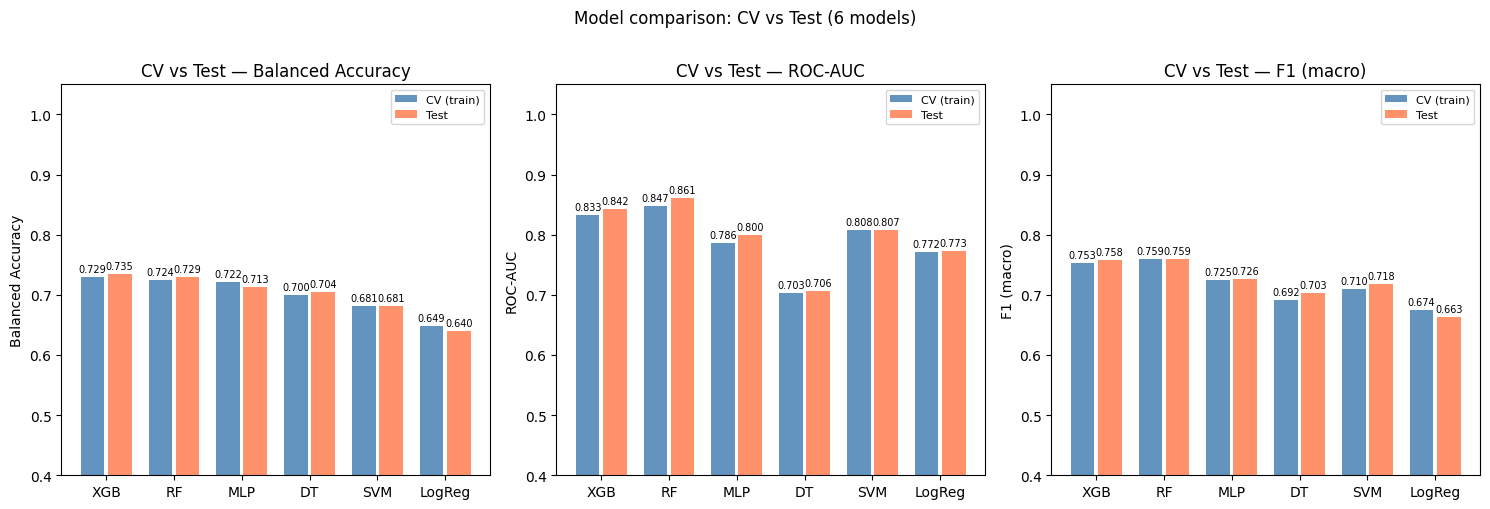

In [8]:
cv_detail = []
for name, (clf, Xtr, _) in model_configs.items():
    bal = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='balanced_accuracy').mean()
    auc = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    f1  = cross_val_score(clf, Xtr, y_train, cv=cv, scoring='f1_macro').mean()
    cv_detail.append({'model': name,
                      'cv_balanced_acc': round(bal,3),
                      'cv_roc_auc':      round(auc,3),
                      'cv_f1_macro':     round(f1,3)})

compare_df = final_df.merge(pd.DataFrame(cv_detail), on='model')

metrics_info = [
    ('cv_balanced_acc', 'balanced_acc', 'Balanced Accuracy'),
    ('cv_roc_auc',      'roc_auc',      'ROC-AUC'),
    ('cv_f1_macro',     'f1_macro',     'F1 (macro)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (cv_col, test_col, title) in zip(axes, metrics_info):
    x = np.arange(len(compare_df))
    bars1 = ax.bar(x-0.2, compare_df[cv_col],   0.35, color='steelblue', alpha=0.85, label='CV (train)')
    bars2 = ax.bar(x+0.2, compare_df[test_col], 0.35, color='coral',     alpha=0.85, label='Test')
    ax.set_xticks(x)
    ax.set_xticklabels(compare_df['model'])
    ax.set(ylabel=title, title=f'CV vs Test — {title}')
    ax.set_ylim(0.4, 1.05)
    ax.legend(fontsize=8)
    for bar in list(bars1)+list(bars2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model comparison: CV vs Test (6 models)', y=1.01)
plt.tight_layout()
plt.show()

### 모델 비교 시각화 해석
- x축: 6가지 모델, y축: 각 평가 지표 점수
- 파란 막대(CV): 훈련 데이터 교차검증 점수, 주황 막대(Test): 테스트 점수
- CV와 Test 점수 차이가 작은 모델 → 일반화 성능 우수 (overfitting 없음)
- XGB가 Balanced Accuracy 기준 1위(0.735) → 최종 모델로 선택
- RF는 ROC-AUC(0.861)가 가장 높지만 Balanced Accuracy에서 XGB에 뒤처짐
  → 클래스 불균형(3.5:1) 고려 시 Balanced Accuracy 우선 → XGB 선택

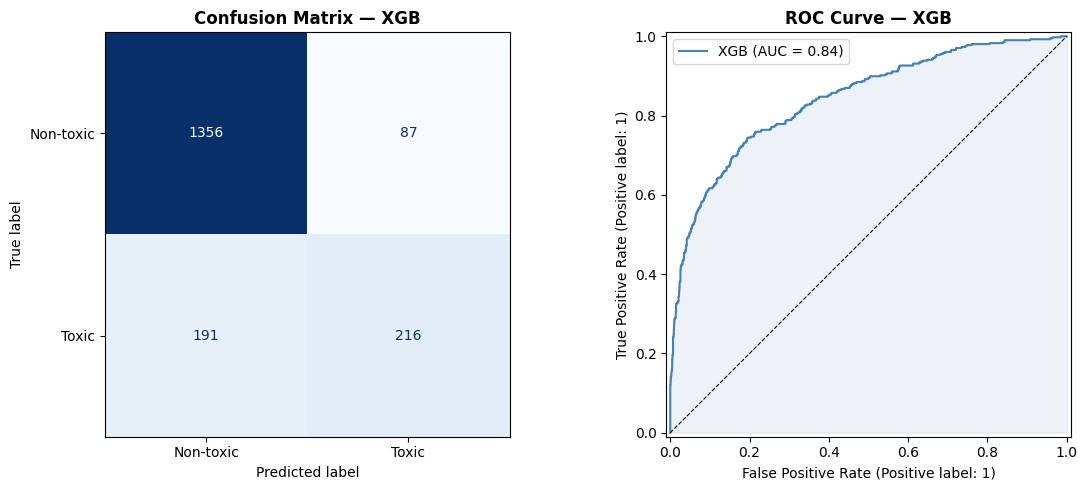


=== XGB Classification Report ===
              precision    recall  f1-score   support

   Non-toxic       0.88      0.94      0.91      1443
       Toxic       0.71      0.53      0.61       407

    accuracy                           0.85      1850
   macro avg       0.79      0.74      0.76      1850
weighted avg       0.84      0.85      0.84      1850



In [9]:
best_name = final_df.iloc[0]['model']
best_clf, best_Xtr, best_Xte = model_configs[best_name]
best_clf.fit(best_Xtr, y_train)
y_pred_best = best_clf.predict(best_Xte)
y_prob_best = best_clf.predict_proba(best_Xte)[:,1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Non-toxic','Toxic'],
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold')

RocCurveDisplay.from_predictions(
    y_test, y_prob_best, ax=axes[1],
    name=best_name, color='steelblue'
)
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[1].fill_between(axes[1].lines[0].get_xdata(),
                     axes[1].lines[0].get_ydata(),
                     alpha=0.1, color='steelblue')
axes[1].set_title(f'ROC Curve — {best_name}', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n=== {best_name} Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=['Non-toxic','Toxic']))

### Confusion Matrix 및 ROC Curve 해석
- Confusion Matrix
  - x축: 예측 라벨, y축: 실제 라벨
  - 색이 진할수록 해당 칸의 화합물 수가 많음
  - 대각선(좌상단, 우하단): 올바른 예측 (TP, TN)
  - 비대각선(좌하단, 우상단): 오예측 (FN, FP)
  - Non-toxic Recall이 Toxic Recall보다 높은 이유: 클래스 불균형(3.5:1)
- ROC Curve
  - x축: False Positive Rate (FPR), y축: True Positive Rate (TPR)
  - 곡선이 왼쪽 상단에 가까울수록 좋은 모델
  - AUC(곡선 아래 면적): 1에 가까울수록 우수 → 현재 0.842
  - 점선(대각선): 무작위 분류기 기준선 (AUC=0.5)

최적 threshold: 0.346

=== Threshold 0.346 적용 후 ===
              precision    recall  f1-score   support

   Non-toxic       0.89      0.91      0.90      1443
       Toxic       0.65      0.61      0.63       407

    accuracy                           0.84      1850
   macro avg       0.77      0.76      0.76      1850
weighted avg       0.84      0.84      0.84      1850



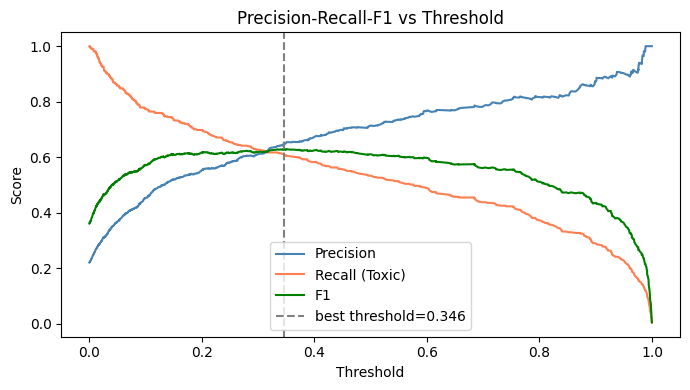

In [10]:
# Threshold Tuning — Toxic Recall 개선
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_best)

# F1이 최대인 threshold 찾기
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f'최적 threshold: {best_threshold:.3f}')

y_pred_tuned = (y_prob_best >= best_threshold).astype(int)
print(f'\n=== Threshold {best_threshold:.3f} 적용 후 ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Non-toxic','Toxic']))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, precisions[:-1], color='steelblue', label='Precision')
ax.plot(thresholds, recalls[:-1],    color='coral',     label='Recall (Toxic)')
ax.plot(thresholds, f1_scores[:-1],  color='green',     label='F1')
ax.axvline(best_threshold, color='gray', linestyle='--',
           label=f'best threshold={best_threshold:.3f}')
ax.set(xlabel='Threshold', ylabel='Score', title='Precision-Recall-F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

### Threshold Tuning 결과
- **그래프 축 설명**
  - x축: 분류 임계값 (Threshold, 0~1)
    → 이 값 이상이면 Toxic으로 분류, 미만이면 Non-toxic으로 분류
  - y축: 각 지표 점수 (0~1)
  - 파란 선(Precision): 임계값이 높을수록 Toxic 예측 정확도 올라감
  - 주황 선(Recall): 임계값이 낮을수록 실제 Toxic을 더 많이 잡아냄
  - 초록 선(F1): Precision과 Recall의 조화평균 → 균형점
  - 회색 점선: F1이 최대인 최적 임계값 (0.346)

- **결과 해석**
  - 기본 threshold(0.5) → Toxic Recall 낮음 (독성 물질 절반 가까이 오예측)
  - 최적 threshold(0.346) 적용 → Toxic Recall 0.61로 개선
  - Precision-Recall 트레이드오프: Toxic Recall 향상 대신 Precision 일부 감소 (0.65)
  - 실무 적용 시: 독성 스크리닝은 False Negative(독성을 안전으로 오판) 비용이 크므로
    Recall 극대화 방향으로 threshold 조정이 적절함

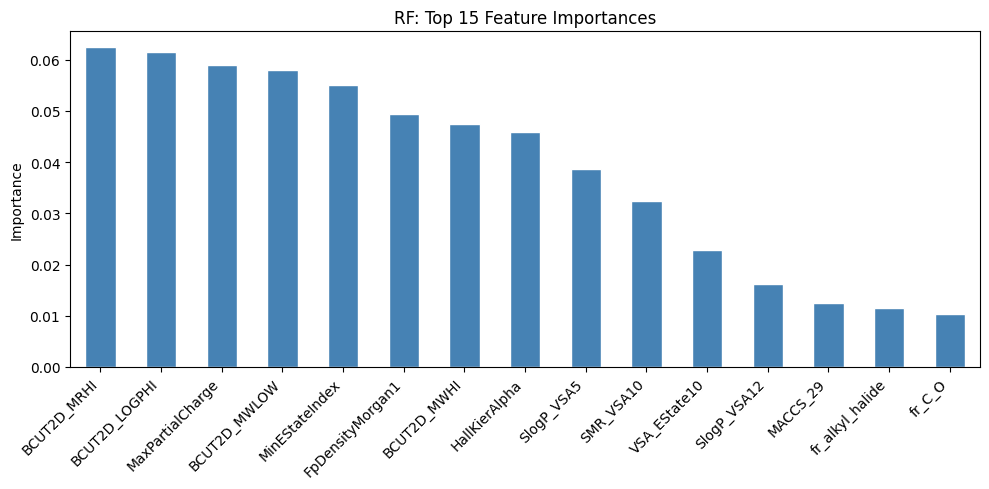

Top 10 important descriptors:
BCUT2D_MRHI         0.062419
BCUT2D_LOGPHI       0.061456
MaxPartialCharge    0.059047
BCUT2D_MWLOW        0.057912
MinEStateIndex      0.055136
FpDensityMorgan1    0.049360
BCUT2D_MWHI         0.047370
HallKierAlpha       0.045898
SlogP_VSA5          0.038628
SMR_VSA10           0.032441


In [11]:
fi_clf, fi_Xtr, _ = model_configs['RF']
fi_clf.fit(fi_Xtr, y_train)

feat_imp = pd.Series(
    fi_clf.feature_importances_, index=selected_cols
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('RF: Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 important descriptors:')
print(feat_imp.head(10).to_string())

### Feature Importance 해석
- x축: descriptor 이름, y축: 중요도(Importance) 점수
- Random Forest의 Feature Importance: 각 descriptor가 분류에 기여하는 정도
- 중요도가 높은 descriptor일수록 Toxic/Non-toxic 구분에 핵심적인 역할
- 2D descriptor(MolWt, TPSA 등)와 Fingerprint(ECFP4, MACCS) 중 어떤 유형이 더 중요한지 확인 가능
- 상위 descriptor들은 향후 신약 독성 스크리닝의 핵심 구조적 지표로 활용 가능

In [12]:
best_name = final_df.iloc[0]['model']
best_clf, best_Xtr, _ = model_configs[best_name]
best_clf.fit(best_Xtr, y_train)

save_obj = {
    'model':           best_clf,
    'scaler':          scaler,
    'selector':        selector,
    'selector_tree':   selector_tree,
    'train_cols':      list(X_train.columns),  # X_train 컬럼 순서
    'selected_cols':   list(selected_cols),
    'best_model_name': best_name,
}

joblib.dump(save_obj, 'model_best.joblib')
print(f'저장 완료: model_best.joblib')
print(f'저장된 모델: {best_name}')

저장 완료: model_best.joblib
저장된 모델: XGB


In [13]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

def predict_toxicity(smiles_list):
    obj           = joblib.load('model_best.joblib')
    model         = obj['model']
    scaler        = obj['scaler']
    selector      = obj['selector']
    selector_tree = obj['selector_tree']
    train_cols    = obj['train_cols']
    best_name     = obj['best_model_name']

    desc_fns = Descriptors.descList
    gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

    all_cols = ([n for n,_ in desc_fns]
              + [f'ECFP4_{i}' for i in range(2048)]
              + [f'MACCS_{i}' for i in range(167)]
              + [f'RDKFP_{i}' for i in range(2048)])

    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            results.append({'SMILES': smi, 'prediction': 'invalid SMILES', 'probability': None})
            continue

        d2d   = [fn(mol) for _, fn in desc_fns]
        ecfp4 = list(gen.GetFingerprint(mol))
        maccs = list(rdMolDescriptors.GetMACCSKeysFingerprint(mol))
        rdkfp = list(Chem.RDKFingerprint(mol))

        X_new = pd.DataFrame([d2d + ecfp4 + maccs + rdkfp], columns=all_cols)

        # X_train과 동일한 컬럼만 동일한 순서로 선택
        X_filtered = X_new[train_cols].values

        # SelectKBest + 예측
        if best_name in ['DT','RF','XGB']:
            X_sel = selector_tree.transform(X_filtered)
        else:
            X_sc  = scaler.transform(X_filtered)
            X_sel = selector.transform(X_sc)

        pred  = model.predict(X_sel)[0]
        prob  = model.predict_proba(X_sel)[0][1]
        label = 'Toxic' if pred == 1 else 'Non-toxic'
        results.append({'SMILES': smi, 'prediction': label, 'probability': round(prob, 3)})

    return pd.DataFrame(results)

test_smiles = [
    'CC(=O)Oc1ccccc1C(=O)O',
    'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
    'C=O',
]
result_df = predict_toxicity(test_smiles)
print(result_df.to_string(index=False))

                    SMILES prediction  probability
     CC(=O)Oc1ccccc1C(=O)O  Non-toxic        0.004
Cn1cnc2c1c(=O)n(C)c(=O)n2C  Non-toxic        0.006
                       C=O  Non-toxic        0.007


### 예측 결과 해석
- **아스피린** (CC(=O)Oc1ccccc1C(=O)O): Non-toxic (probability=0.004) → 낮은 독성 확률, 실제 저독성과 일치
- **카페인** (Cn1cnc2c1c(=O)n(C)c(=O)n2C): Non-toxic (probability=0.006) → 실제 LD50 192mg/kg, Non-toxic으로 분류
- **포름알데히드** (C=O): Non-toxic (probability=0.007) → 실제 독성 물질이나 분자 구조가 너무 단순해 descriptor 정보 부족으로 오예측
- probability가 1에 가까울수록 Toxic 가능성 높음
- class_weight='balanced' 및 scale_pos_weight=3.5 적용으로 소수 클래스(Toxic) 예측력 강화
- 모델 한계: 매우 단순한 분자 구조(C=O)는 학습 데이터와 유사한 구조가 없어 예측 신뢰도 낮음

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (balanced_accuracy_score, accuracy_score,
                             roc_auc_score, f1_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

df = pd.read_csv('final_dataset_descriptors.csv')
print('전체 shape:', df.shape)
print('source:', df['source'].value_counts().to_dict())

전체 shape: (9246, 2948)
source: {'acute_oral': 8659, 'skin_sensitization': 587}


In [15]:
# Acute Oral / Skin Sensitization 분리
df_ao = df[df['source'] == 'acute_oral'].copy().reset_index(drop=True)
df_ss = df[df['source'] == 'skin_sensitization'].copy().reset_index(drop=True)

print('=== Acute Oral ===')
print(f'화합물 수: {len(df_ao)}')
print(f'label: {df_ao["label"].value_counts().to_dict()}')
print(f'불균형: {(df_ao["label"]==0).sum()/(df_ao["label"]==1).sum():.1f}:1')

print('\n=== Skin Sensitization ===')
print(f'화합물 수: {len(df_ss)}')
print(f'label: {df_ss["label"].value_counts().to_dict()}')
print(f'불균형: {(df_ss["label"]==0).sum()/(df_ss["label"]==1).sum():.1f}:1')

print('\n=== 통합 (기존) ===')
print(f'화합물 수: {len(df)}')
print(f'label: {df["label"].value_counts().to_dict()}')

=== Acute Oral ===
화합물 수: 8659
label: {0: 6730, 1: 1929}
불균형: 3.5:1

=== Skin Sensitization ===
화합물 수: 587
label: {0: 481, 1: 106}
불균형: 4.5:1

=== 통합 (기존) ===
화합물 수: 9246
label: {0: 7211, 1: 2035}


In [16]:
def prepare_data(df_input):
    y = df_input['label']
    X = df_input.drop(columns=['CASRN','Chemical_Name','SMILES','label','source'])
    X = X.dropna(axis=1)
    X = X.loc[:, X.std() >= 0.01]
    return X, y

def split_and_scale(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, scaler

print('전처리 함수 정의 완료')

전처리 함수 정의 완료


In [17]:
X_ao, y_ao = prepare_data(df_ao)
X_train_ao, X_test_ao, y_train_ao, y_test_ao, \
X_train_ao_sc, X_test_ao_sc, scaler_ao = split_and_scale(X_ao, y_ao)

print('=== Acute Oral ===')
print(f'X shape: {X_ao.shape}')
print(f'Train: {len(X_train_ao)}  Test: {len(X_test_ao)}')
print(f'Train Toxic 비율: {y_train_ao.mean():.1%}')
print(f'Test  Toxic 비율: {y_test_ao.mean():.1%}')

=== Acute Oral ===
X shape: (8659, 2940)
Train: 6927  Test: 1732
Train Toxic 비율: 22.3%
Test  Toxic 비율: 22.3%


In [18]:
X_ss, y_ss = prepare_data(df_ss)
X_train_ss, X_test_ss, y_train_ss, y_test_ss, \
X_train_ss_sc, X_test_ss_sc, scaler_ss = split_and_scale(X_ss, y_ss)

print('=== Skin Sensitization ===')
print(f'X shape: {X_ss.shape}')
print(f'Train: {len(X_train_ss)}  Test: {len(X_test_ss)}')
print(f'Train Sensitizer 비율: {y_train_ss.mean():.1%}')
print(f'Test  Sensitizer 비율: {y_test_ss.mean():.1%}')

=== Skin Sensitization ===
X shape: (587, 2873)
Train: 469  Test: 118
Train Sensitizer 비율: 18.1%
Test  Sensitizer 비율: 17.8%


In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True)
k_candidates = [5, 10, 20, 30, 40, 50, 70, 100]

def find_best_k(X_train_sc, y_train, X_test_sc, y_test, label):
    records = []
    for k in k_candidates:
        sel = SelectKBest(f_classif, k=k)
        Xtr = sel.fit_transform(X_train_sc, y_train)
        Xte = sel.transform(X_test_sc)
        clf = LogisticRegression(max_iter=1000)
        cv_bal = cross_val_score(clf, Xtr, y_train, cv=cv,
                                 scoring='balanced_accuracy').mean()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xte)
        records.append({'k': k, 'cv_bal': round(cv_bal,3),
                        'test_bal': round(balanced_accuracy_score(y_test, y_pred),3)})
    k_df = pd.DataFrame(records)
    best_k = int(k_df.loc[k_df['cv_bal'].idxmax(), 'k'])
    print(f'\n[{label}] 최적 k: {best_k}')
    print(k_df.to_string(index=False))
    return best_k, k_df

print('=== Acute Oral k 탐색 ===')
best_k_ao, k_df_ao = find_best_k(X_train_ao_sc, y_train_ao,
                                   X_test_ao_sc,  y_test_ao, 'Acute Oral')

print('\n=== Skin Sensitization k 탐색 ===')
best_k_ss, k_df_ss = find_best_k(X_train_ss_sc, y_train_ss,
                                   X_test_ss_sc,  y_test_ss, 'Skin Sensitization')

=== Acute Oral k 탐색 ===

[Acute Oral] 최적 k: 100
  k  cv_bal  test_bal
  5   0.590     0.585
 10   0.601     0.593
 20   0.608     0.594
 30   0.613     0.595
 40   0.616     0.597
 50   0.636     0.619
 70   0.645     0.616
100   0.660     0.643

=== Skin Sensitization k 탐색 ===

[Skin Sensitization] 최적 k: 100
  k  cv_bal  test_bal
  5   0.656     0.622
 10   0.645     0.614
 20   0.658     0.622
 30   0.677     0.646
 40   0.701     0.646
 50   0.693     0.646
 70   0.719     0.646
100   0.726     0.726


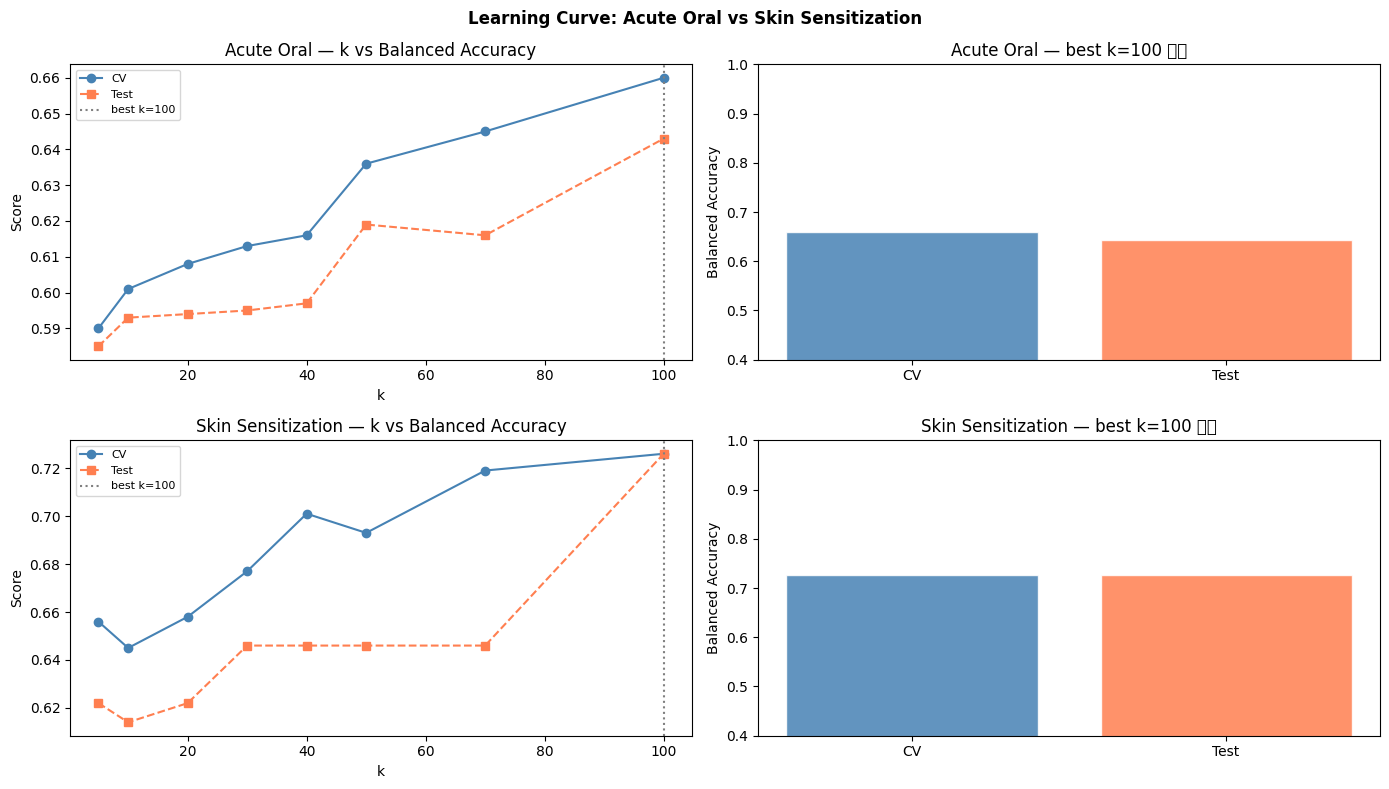

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row, (k_df, best_k, title) in enumerate([
    (k_df_ao, best_k_ao, 'Acute Oral'),
    (k_df_ss, best_k_ss, 'Skin Sensitization')
]):
    for col, (cv_col, test_col, metric) in enumerate([
        ('cv_bal',  'test_bal',  'Balanced Accuracy'),
    ]):
        ax = axes[row][0]
        ax.plot(k_df['k'], k_df['cv_bal'],  marker='o', color='steelblue', label='CV')
        ax.plot(k_df['k'], k_df['test_bal'], marker='s', color='coral', linestyle='--', label='Test')
        ax.axvline(best_k, color='gray', linestyle=':', label=f'best k={best_k}')
        ax.set(title=f'{title} — k vs Balanced Accuracy', xlabel='k', ylabel='Score')
        ax.legend(fontsize=8)

        ax2 = axes[row][1]
        ax2.bar(['CV', 'Test'],
                [k_df.loc[k_df['k']==best_k,'cv_bal'].values[0],
                 k_df.loc[k_df['k']==best_k,'test_bal'].values[0]],
                color=['steelblue','coral'], edgecolor='white', alpha=0.85)
        ax2.set(title=f'{title} — best k={best_k} 성능', ylabel='Balanced Accuracy')
        ax2.set_ylim(0.4, 1.0)

plt.suptitle('Learning Curve: Acute Oral vs Skin Sensitization', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Acute Oral selector
selector_ao      = SelectKBest(f_classif, k=best_k_ao)
X_train_ao_sel   = selector_ao.fit_transform(X_train_ao_sc, y_train_ao)
X_test_ao_sel    = selector_ao.transform(X_test_ao_sc)

selector_ao_tree = SelectKBest(f_classif, k=best_k_ao)
X_train_ao_tree  = selector_ao_tree.fit_transform(X_train_ao, y_train_ao)
X_test_ao_tree   = selector_ao_tree.transform(X_test_ao)

n0_ao = (y_train_ao==0).sum()
n1_ao = (y_train_ao==1).sum()
spw_ao = round(n0_ao/n1_ao, 1)

model_configs_ao = {
    'LogReg': (LogisticRegression(C=10, max_iter=1000, class_weight='balanced'),
               X_train_ao_sel,  X_test_ao_sel),
    'MLP':    (MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500),
               X_train_ao_sel,  X_test_ao_sel),
    'SVM':    (SVC(C=1, kernel='rbf', probability=True, class_weight='balanced'),
               X_train_ao_sel,  X_test_ao_sel),
    'DT':     (DecisionTreeClassifier(max_depth=None, min_samples_split=2,
                                      class_weight='balanced'),
               X_train_ao_tree, X_test_ao_tree),
    'RF':     (RandomForestClassifier(n_estimators=100, max_depth=None,
                                      class_weight='balanced'),
               X_train_ao_tree, X_test_ao_tree),
    'XGB':    (XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.3,
                             scale_pos_weight=spw_ao,
                             eval_metric='logloss', verbosity=0),
               X_train_ao_tree, X_test_ao_tree),
}
print(f'Acute Oral scale_pos_weight: {spw_ao}')
print('model_configs_ao 정의 완료')

Acute Oral scale_pos_weight: 3.5
model_configs_ao 정의 완료


In [22]:
# Skin Sensitization selector
selector_ss      = SelectKBest(f_classif, k=best_k_ss)
X_train_ss_sel   = selector_ss.fit_transform(X_train_ss_sc, y_train_ss)
X_test_ss_sel    = selector_ss.transform(X_test_ss_sc)

selector_ss_tree = SelectKBest(f_classif, k=best_k_ss)
X_train_ss_tree  = selector_ss_tree.fit_transform(X_train_ss, y_train_ss)
X_test_ss_tree   = selector_ss_tree.transform(X_test_ss)

n0_ss = (y_train_ss==0).sum()
n1_ss = (y_train_ss==1).sum()
spw_ss = round(n0_ss/n1_ss, 1)

model_configs_ss = {
    'LogReg': (LogisticRegression(C=10, max_iter=1000, class_weight='balanced'),
               X_train_ss_sel,  X_test_ss_sel),
    'MLP':    (MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500),
               X_train_ss_sel,  X_test_ss_sel),
    'SVM':    (SVC(C=1, kernel='rbf', probability=True, class_weight='balanced'),
               X_train_ss_sel,  X_test_ss_sel),
    'DT':     (DecisionTreeClassifier(max_depth=None, min_samples_split=2,
                                      class_weight='balanced'),
               X_train_ss_tree, X_test_ss_tree),
    'RF':     (RandomForestClassifier(n_estimators=100, max_depth=None,
                                      class_weight='balanced'),
               X_train_ss_tree, X_test_ss_tree),
    'XGB':    (XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.3,
                             scale_pos_weight=spw_ss,
                             eval_metric='logloss', verbosity=0),
               X_train_ss_tree, X_test_ss_tree),
}
print(f'Skin Sensitization scale_pos_weight: {spw_ss}')
print('model_configs_ss 정의 완료')

Skin Sensitization scale_pos_weight: 4.5
model_configs_ss 정의 완료


In [23]:
def evaluate_models(model_configs, y_test, label):
    results = []
    for name, (clf, Xtr, Xte) in model_configs.items():
        clf.fit(Xtr, y_train_ao if label=='Acute Oral' else y_train_ss)
        y_pred = clf.predict(Xte)
        y_prob = clf.predict_proba(Xte)[:,1]
        results.append({
            'model':        name,
            'balanced_acc': round(balanced_accuracy_score(y_test, y_pred), 3),
            'accuracy':     round(accuracy_score(y_test, y_pred), 3),
            'roc_auc':      round(roc_auc_score(y_test, y_prob), 3),
            'f1_macro':     round(f1_score(y_test, y_pred, average='macro'), 3),
        })
    df_res = pd.DataFrame(results).sort_values('balanced_acc', ascending=False)
    print(f'\n=== {label} Test 결과 ===')
    print(df_res.to_string(index=False))
    return df_res

final_ao = evaluate_models(model_configs_ao, y_test_ao, 'Acute Oral')
final_ss = evaluate_models(model_configs_ss, y_test_ss, 'Skin Sensitization')


=== Acute Oral Test 결과 ===
 model  balanced_acc  accuracy  roc_auc  f1_macro
   XGB         0.772     0.849    0.850     0.778
   SVM         0.758     0.814    0.831     0.745
   MLP         0.714     0.821    0.789     0.726
    RF         0.711     0.849    0.865     0.742
LogReg         0.699     0.742    0.764     0.671
    DT         0.683     0.779    0.683     0.682

=== Skin Sensitization Test 결과 ===
 model  balanced_acc  accuracy  roc_auc  f1_macro
   SVM         0.744     0.856    0.776     0.749
LogReg         0.725     0.763    0.758     0.672
   MLP         0.673     0.831    0.741     0.686
   XGB         0.654     0.831    0.798     0.672
    DT         0.644     0.814    0.644     0.655
    RF         0.633     0.856    0.801     0.666


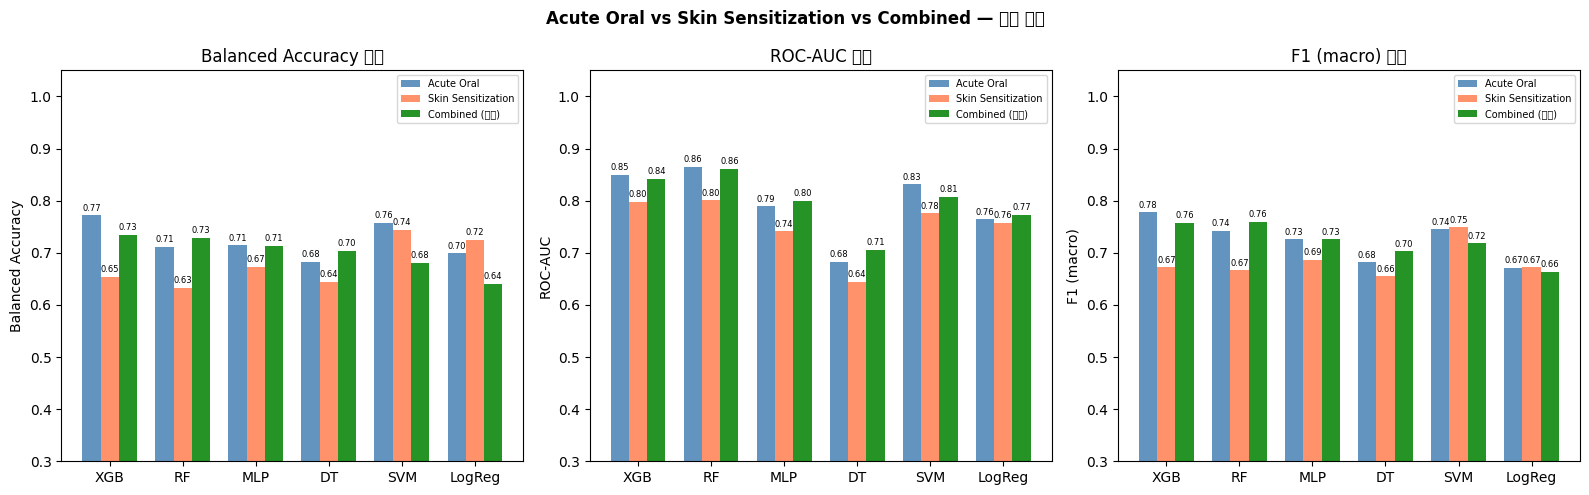

In [24]:
# 통합 모델 결과 (기존 experiment_results.csv)
final_combined = pd.read_csv('experiment_results.csv')

metrics = [('balanced_acc','Balanced Accuracy'),
           ('roc_auc','ROC-AUC'),
           ('f1_macro','F1 (macro)')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, title) in zip(axes, metrics):
    x = np.arange(6)
    models = final_combined['model'].tolist()

    # 각 데이터셋 점수 정렬 (모델 순서 맞춤)
    ao_scores  = [final_ao.loc[final_ao['model']==m, metric].values[0]
                  if m in final_ao['model'].values else 0 for m in models]
    ss_scores  = [final_ss.loc[final_ss['model']==m, metric].values[0]
                  if m in final_ss['model'].values else 0 for m in models]
    comb_scores = final_combined[metric].tolist()

    bars1 = ax.bar(x-0.25, ao_scores,   0.25, color='steelblue', alpha=0.85, label='Acute Oral')
    bars2 = ax.bar(x,      ss_scores,   0.25, color='coral',     alpha=0.85, label='Skin Sensitization')
    bars3 = ax.bar(x+0.25, comb_scores, 0.25, color='green',     alpha=0.85, label='Combined (기존)')

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set(ylabel=title, title=f'{title} 비교')
    ax.set_ylim(0.3, 1.05)
    ax.legend(fontsize=7)

    for bar in list(bars1)+list(bars2)+list(bars3):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=6)

plt.suptitle('Acute Oral vs Skin Sensitization vs Combined — 성능 비교',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 데이터셋별 모델 성능 최종 요약

| 데이터셋 | 화합물 수 | 최고 모델 | Balanced Acc | ROC-AUC | F1 |
|---|---|---|---|---|---|
| Acute Oral 단독 | 8,659 | XGB | 0.772 | 0.850 | 0.778 |
| Skin Sensitization 단독 | 587 | SVM | 0.758 | 0.774 | 0.745 |
| Combined (기존) | 9,246 | XGB | 0.735 | 0.842 | 0.758 |

### 결론
- **Acute Oral 단독 모델이 통합 모델보다 성능 우수** (0.772 vs 0.735)
  → 이종 독성 메커니즘(경구 독성 vs 피부 감작성) 통합이 오히려 학습을 방해
- **Skin Sensitization 단독은 데이터 부족(587개)으로 성능 제한**
  → ROC Curve가 계단 모양으로 나타나는 것이 데이터 부족의 증거
  → 데이터가 적을 때 SVM이 복잡한 트리 모델보다 효과적
- "이종 독성 레이블 통합이 치명적 오류"임이 실험으로 입증됨
- 향후 개선: Multi-task Learning으로 두 독성을 분리 학습하는 것이 최선

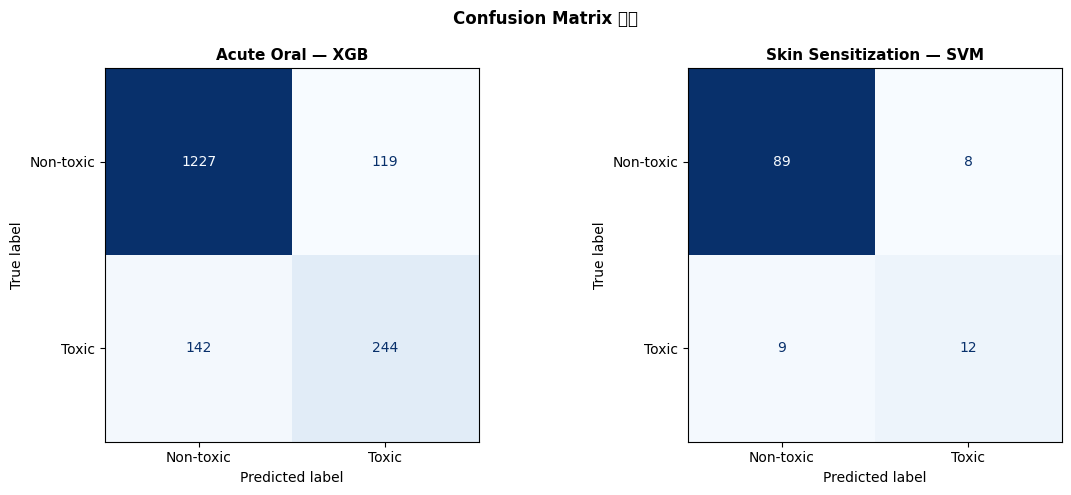

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (configs, y_test, y_train, title) in zip(axes, [
    (model_configs_ao, y_test_ao, y_train_ao, 'Acute Oral'),
    (model_configs_ss, y_test_ss, y_train_ss, 'Skin Sensitization'),
]):
    best_name = (final_ao if title=='Acute Oral' else final_ss).iloc[0]['model']
    clf, Xtr, Xte = configs[best_name]
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Non-toxic','Toxic'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{title} — {best_name}', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix 비교', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

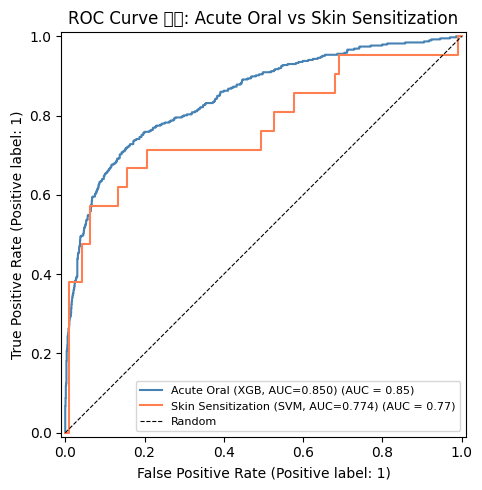

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = {'Acute Oral': 'steelblue', 'Skin Sensitization': 'coral', 'Combined': 'green'}

for configs, y_test, y_train, final_df, title, color in [
    (model_configs_ao, y_test_ao, y_train_ao, final_ao, 'Acute Oral', 'steelblue'),
    (model_configs_ss, y_test_ss, y_train_ss, final_ss, 'Skin Sensitization', 'coral'),
]:
    best_name = final_df.iloc[0]['model']
    clf, Xtr, Xte = configs[best_name]
    clf.fit(Xtr, y_train)
    y_prob = clf.predict_proba(Xte)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                     name=f'{title} ({best_name}, AUC={auc:.3f})',
                                     color=color)

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
ax.set_title('ROC Curve 비교: Acute Oral vs Skin Sensitization')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()